# FAQ Chatbot — Fine-tuning `distilbert-base-multilingual-cased`

**Abordagem:** classificação de intenções (intent classification).  
O modelo aprende a mapear uma pergunta do usuário para uma **classe/intenção** (cada FAQ é uma classe).  
Na inferência, dado o índice previsto, o chatbot retorna a resposta correspondente.

```
Pergunta do usuário → DistilBERT → logits → argmax → intent_id → resposta fixa
```

> **Modelo base:** `distilbert-base-multilingual-cased`  
> Suporta 104 idiomas, incluindo Português, Inglês, Espanhol, etc.

## 0. Instalações

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy accelerate -q

## 1. Estrutura e preparação do dataset

### Formato esperado: `faq_dataset.json`

Cada entrada representa uma **intenção** (intent). O campo `questions` contém **variações** da mesma pergunta — quanto mais variações, melhor a generalização.

**Dicas para preparação:**
- Mínimo recomendado: **5–10 variações por intenção**
- Use sinônimos, reordenações e formulações diferentes
- Inclua erros de digitação comuns se quiser robustez
- Mínimo de **2 intenções** para classificação funcionar
- Salve o arquivo como `faq_dataset.json` no mesmo diretório do notebook

## 2. Imports e configurações gerais

In [ ]:
import json
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    DistilBertConfig,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME               = 'distilbert-base-multilingual-cased'
DATASET_PATH             = 'faq_dataset_v4.json'

# ── TOKENIZAÇÃO ───────────────────────────────────────────────────────────────
# FIX 4: aumentado de 64 → 96 para capturar perguntas mais longas e variadas
MAX_LEN                  = 96

# ── TREINO ────────────────────────────────────────────────────────────────────
BATCH_SIZE               = 16
EPOCHS                   = 50
EARLY_STOPPING_PATIENCE  = 5

# FIX 3: LR ligeiramente maior para o modelo explorar mais o espaço
LEARNING_RATE            = 3e-5

# FIX 3: weight_decay maior reduz overfitting (era 0.01)
WEIGHT_DECAY             = 0.05

# FIX 3: warmup maior (era 10%) — deixa o modelo estabilizar antes de aprender
WARMUP_RATIO             = 0.15

# FIX 2: dropout maior nas camadas de classificação (padrão era 0.1 / 0.2)
ATTENTION_DROPOUT        = 0.2
SEQ_CLASSIF_DROPOUT      = 0.4

# FIX 5: congela as primeiras N camadas do transformer (0 = treina tudo)
# DistilBERT tem 6 camadas. Congelar 3 primeiras deixa as últimas 3 livres.
FREEZE_LAYERS            = 3

TEST_SIZE                = 0.22  # FIX: ajustado para dataset pequeno (242 ex / 48 classes)
SAVE_DIR                 = './faq_model'

# FIX 6: threshold menor — com mais dropout a confiança fica mais distribuída
CONFIDENCE_THRESHOLD     = 0.20

# FIX 6: temperature scaling — divide logits por T antes do softmax
# T=1.5 suaviza a distribuição, aceita perguntas com wording diferente
TEMPERATURE              = 1.5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
print(f'MAX_LEN={MAX_LEN} | LR={LEARNING_RATE} | WD={WEIGHT_DECAY} | '
      f'warmup={WARMUP_RATIO:.0%} | dropout_attn={ATTENTION_DROPOUT} | '
      f'dropout_clf={SEQ_CLASSIF_DROPOUT} | freeze={FREEZE_LAYERS} camadas | '
      f'threshold={CONFIDENCE_THRESHOLD} | T={TEMPERATURE}')


/home/caique/Desktop/faq_chatbot/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cuda
MAX_LEN=96 | LR=3e-05 | WD=0.05 | warmup=15% | dropout_attn=0.2 | dropout_clf=0.4 | freeze=3 camadas | threshold=0.28 | T=1.5


## 3. Carregamento e preparação do dataset

In [3]:
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

intents       = [entry['intent'] for entry in raw_data]
intent2idx    = {intent: idx for idx, intent in enumerate(intents)}
idx2intent    = {idx: intent for intent, idx in intent2idx.items()}
intent2answer = {entry['intent']: entry['answer'] for entry in raw_data}
num_labels    = len(intents)

print(f'Intenções encontradas ({num_labels}): {intents}')

texts, labels = [], []
for entry in raw_data:
    for question in entry['questions']:
        texts.append(question)
        labels.append(intent2idx[entry['intent']])

print(f'Total de exemplos: {len(texts)}')
print(f'Média de variações por intent: {len(texts)/num_labels:.1f}')

# ── Split robusto para datasets pequenos ──────────────────────────────────────
# Com poucos exemplos por classe, o stratify do sklearn exige que o split de
# validação tenha pelo menos 1 exemplo de cada classe.
# Regra: TEST_SIZE >= num_labels / total_examples
min_test_size = num_labels / len(texts)
safe_test_size = max(TEST_SIZE, min_test_size + 0.05)  # +5% de margem
print(f'TEST_SIZE mínimo seguro: {min_test_size:.2f} | usando: {safe_test_size:.2f}')

# Tenta com stratify; se falhar (alguma classe com 1 único exemplo), usa sem
try:
    X_train, X_val, y_train, y_val = train_test_split(
        texts, labels,
        test_size=safe_test_size,
        stratify=labels,
        random_state=SEED,
    )
    print('Split com stratify OK')
except ValueError as e:
    print(f'Stratify falhou ({e}). Usando split simples.')
    X_train, X_val, y_train, y_val = train_test_split(
        texts, labels,
        test_size=safe_test_size,
        random_state=SEED,
    )

print(f'Treino: {len(X_train)} | Validação: {len(X_val)}')

# ── Aviso de dataset pequeno ──────────────────────────────────────────────────
avg = len(texts) / num_labels
if avg < 15:
    print(f'\n⚠️  AVISO: média de {avg:.1f} variações/intent é baixa.')
    print('   Recomendado: 30–50 variações por intent para boa generalização.')
    print('   Dica: use o script de augmentation para expandir seu dataset.')


Intenções encontradas (48): ['estao_cobrando_um_seguro_em_meu_cartao_de_credito_que_eu_nao', 'estao_descontando_um_emprestimo_ja_quitado_na_minha_folha_de', 'estao_descontando_do_meu_beneficio_um_valor_referente_a_um_e', 'nao_querem_entregar_meu_contrato', 'tenho_um_plano_de_telefone_e_quero_cancelar_e_nao_estou_cons', 'estao_cobrando_no_meu_beneficio_um_valor_referente_a_rmc_e_r', 'comprei_um_produto_atraves_de_determinada_loja_de_uma_plataf', 'fiz_uma_reclamacao_atraves_do_procon_online_mas_nao_consegui', 'fui_cancelar_o_contrato_e_foi_cobrado_uma_multa_pode', 'um_contrato_pode_ter_fidelidade', 'arrependimento_de_7_dias', 'vale_para_compra_em_loja_fisica', 'quem_paga_o_frete_de_devolucao', 'abri_a_embalagem_e_usei_o_produto_ainda_posso_devolver', 'o_prazo_de_entrega_nao_foi_respeitado_e_agora', 'o_que_e_vicio_aparente', 'o_que_e_vicio_oculto', 'como_contar_o_prazo_no_vicio_oculto', 'prazos_para_reclamacao', 'vicio_ou_defeito', 'apos_receber_um_produto_novo_atraves_da_garantia_como_fi

## 4. Tokenizador e Dataset PyTorch

In [4]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class FAQDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="longest",  # FIX 4: evita padding desnecessário, melhora generalização,
            max_length=max_len,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

train_dataset = FAQDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = FAQDataset(X_val,   y_val,   tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print("Datasets e DataLoaders prontos.")

Datasets e DataLoaders prontos.


## 5. Modelo, otimizador e scheduler

In [5]:
# FIX 2: configura dropout customizado antes de carregar o modelo
config = DistilBertConfig.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    attention_dropout=ATTENTION_DROPOUT,      # era 0.1
    seq_classif_dropout=SEQ_CLASSIF_DROPOUT,  # era 0.2
)
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config,
    ignore_mismatched_sizes=True,
)

# FIX 5: congela as primeiras FREEZE_LAYERS camadas do transformer
# Isso preserva os embeddings pré-treinados e reduz overfitting
if FREEZE_LAYERS > 0:
    for i, layer in enumerate(model.distilbert.transformer.layer):
        if i < FREEZE_LAYERS:
            for param in layer.parameters():
                param.requires_grad = False
    print(f'Camadas 0–{FREEZE_LAYERS-1} congeladas. '
          f'Camadas {FREEZE_LAYERS}–5 treináveis.')

model.to(DEVICE)

# FIX 3: weight_decay aumentado
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parâmetros treináveis: {trainable:,} / {total:,} '
      f'({trainable/total:.1%})')
print(f'Steps totais: {total_steps} | Warmup: {warmup_steps}')


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4659.35it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Camadas 0–2 congeladas. Camadas 3–5 treináveis.
Parâmetros treináveis: 114,097,968 / 135,361,584 (84.3%)
Steps totais: 1200 | Warmup: 180


## 6. Loop de treinamento

In [6]:
def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch   = batch["labels"].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels_batch,
            )
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels_batch).sum().item()
            total   += labels_batch.size(0)
    return total_loss / len(loader), correct / total


best_val_acc    = 0.0
patience_counter = 0  # FIX: early stopping counter
history = []

for epoch in range(1, EPOCHS + 1):
    # ── Treino ─────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0
    for batch in train_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch   = batch["labels"].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch,
        )
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += outputs.loss.item()
    train_loss /= len(train_loader)

    # ── Validação ──────────────────────────────────────────────────────────
    val_loss, val_acc = evaluate(model, val_loader, DEVICE)
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "val_loss": val_loss, "val_acc": val_acc})

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # ── Salva melhor modelo ─────────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0  # FIX: reseta o contador
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"   ↳ Melhor modelo salvo (val_acc={val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\n⏹  Early stopping na epoch {epoch} "
                  f"(sem melhora por {EARLY_STOPPING_PATIENCE} epochs)")
            break

print(f"\nTreinamento concluído. Melhor val_acc: {best_val_acc:.4f}")


Epoch 01/50 | Train Loss: 3.8719 | Val Loss: 3.8735 | Val Acc: 0.0187


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.89it/s]


   ↳ Melhor modelo salvo (val_acc=0.0187)
Epoch 02/50 | Train Loss: 3.8862 | Val Loss: 3.8703 | Val Acc: 0.0187
Epoch 03/50 | Train Loss: 3.8699 | Val Loss: 3.8593 | Val Acc: 0.0187
Epoch 04/50 | Train Loss: 3.8489 | Val Loss: 3.8425 | Val Acc: 0.0654


Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.62s/it]


   ↳ Melhor modelo salvo (val_acc=0.0654)
Epoch 05/50 | Train Loss: 3.8245 | Val Loss: 3.7986 | Val Acc: 0.0654
Epoch 06/50 | Train Loss: 3.7308 | Val Loss: 3.6879 | Val Acc: 0.1215


...

   ↳ Melhor modelo salvo (val_acc=0.7757)
Epoch 21/50 | Train Loss: 0.8186 | Val Loss: 1.2996 | Val Acc: 0.7664
Epoch 22/50 | Train Loss: 0.7299 | Val Loss: 1.2100 | Val Acc: 0.7664
Epoch 23/50 | Train Loss: 0.6235 | Val Loss: 1.1446 | Val Acc: 0.7944


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.41s/it]


   ↳ Melhor modelo salvo (val_acc=0.7944)
Epoch 24/50 | Train Loss: 0.5594 | Val Loss: 1.0833 | Val Acc: 0.8131


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.67s/it]


   ↳ Melhor modelo salvo (val_acc=0.8131)
Epoch 25/50 | Train Loss: 0.4569 | Val Loss: 1.0217 | Val Acc: 0.7944
Epoch 26/50 | Train Loss: 0.4015 | Val Loss: 0.9872 | Val Acc: 0.7850
Epoch 27/50 | Train Loss: 0.3544 | Val Loss: 0.9428 | Val Acc: 0.8037
Epoch 28/50 | Train Loss: 0.3120 | Val Loss: 0.9142 | Val Acc: 0.7850
Epoch 29/50 | Train Loss: 0.2751 | Val Loss: 0.8867 | Val Acc: 0.7850

⏹  Early stopping na epoch 29 (sem melhora por 5 epochs)

Treinamento concluído. Melhor val_acc: 0.8131


## 7. Relatório de classificação detalhado

In [7]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch   = batch["labels"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=-1).cpu()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels_batch.tolist())

target_names = [idx2intent[i] for i in range(num_labels)]
print(classification_report(all_labels, all_preds, target_names=target_names))

                                                              precision    recall  f1-score   support

estao_cobrando_um_seguro_em_meu_cartao_de_credito_que_eu_nao       0.67      1.00      0.80         2
estao_descontando_um_emprestimo_ja_quitado_na_minha_folha_de       1.00      1.00      1.00         2
estao_descontando_do_meu_beneficio_um_valor_referente_a_um_e       1.00      1.00      1.00         2
                            nao_querem_entregar_meu_contrato       0.50      1.00      0.67         2
tenho_um_plano_de_telefone_e_quero_cancelar_e_nao_estou_cons       1.00      1.00      1.00         2
estao_cobrando_no_meu_beneficio_um_valor_referente_a_rmc_e_r       0.67      1.00      0.80         2
comprei_um_produto_atraves_de_determinada_loja_de_uma_plataf       1.00      1.00      1.00         2
fiz_uma_reclamacao_atraves_do_procon_online_mas_nao_consegui       1.00      1.00      1.00         3
        fui_cancelar_o_contrato_e_foi_cobrado_uma_multa_pode       1.00      1.00

/home/caique/Desktop/faq_chatbot/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/caique/Desktop/faq_chatbot/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/caique/Desktop/faq_chatbot/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

## 8. Curva de treinamento

In [8]:
!pip install matplotlib

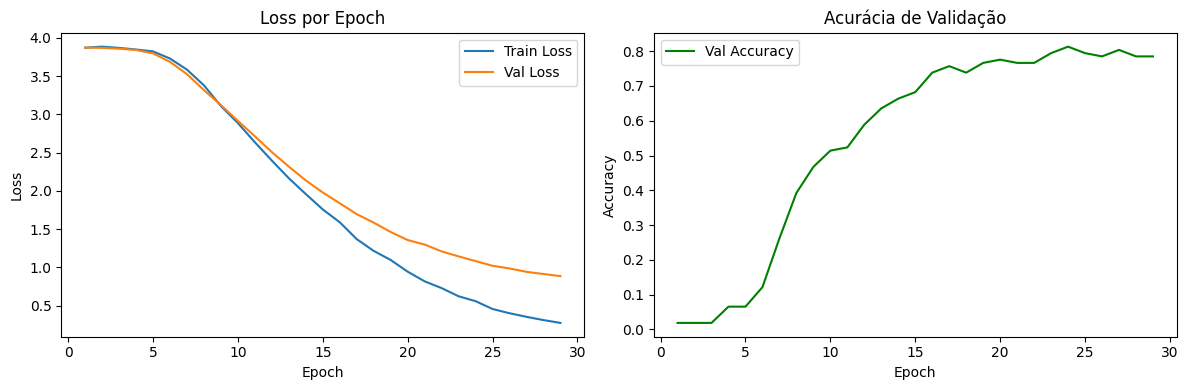

In [9]:
import matplotlib.pyplot as plt

df_history = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df_history["epoch"], df_history["train_loss"], label="Train Loss")
ax1.plot(df_history["epoch"], df_history["val_loss"],   label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss por Epoch"); ax1.legend()

ax2.plot(df_history["epoch"], df_history["val_acc"], color="green", label="Val Accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Acurácia de Validação"); ax2.legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=120)
plt.show()

## 9. Inferência — chatbot interativo

Carrega o **melhor modelo salvo** e responde perguntas em tempo real.

In [ ]:
import torch.nn.functional as F

# ── Carrega modelo salvo ───────────────────────────────────────────────────────
infer_tokenizer = DistilBertTokenizerFast.from_pretrained(SAVE_DIR)
infer_model     = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR)
infer_model.to(DEVICE)
infer_model.eval()

def predict(question: str):
    """Retorna (intent, resposta, confiança, top3)."""
    encoding = infer_tokenizer(
        question,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )
    input_ids      = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits = infer_model(input_ids=input_ids, attention_mask=attention_mask).logits

    # FIX 6: temperature scaling — suaviza a distribuição de probabilidade
    # T > 1 faz o modelo aceitar perguntas com wording diferente do treino
    probs      = F.softmax(logits / TEMPERATURE, dim=-1).squeeze()
    top3_vals, top3_idxs = probs.topk(3)
    top3 = [(idx2intent[i.item()], v.item()) for i, v in zip(top3_idxs, top3_vals)]

    confidence = probs.max().item()
    intent_idx = probs.argmax().item()
    intent     = idx2intent[intent_idx]
    answer     = intent2answer[intent]
    return intent, answer, confidence, top3


def chat(question: str, debug: bool = False):
    intent, answer, confidence, top3 = predict(question)
    if debug:
        print(f"  [debug] top-3 intents:")
        for name, prob in top3:
            print(f"    {prob:.4f}  {name}")
    if confidence < CONFIDENCE_THRESHOLD:
        return (f"⚠️  Desculpe, não encontrei uma resposta "
                f"(confiança={confidence:.2%} < threshold={CONFIDENCE_THRESHOLD:.0%}). "
                f"Tente reformular sua pergunta.")
    return f"{answer}  [intent={intent}, confiança={confidence:.2%}]"



Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3594.59it/s]

Threshold ativo: 28%

Q: quais os tipos de garantia
  [debug] top-3 intents:
    0.3878  quais_sao_os_tipos_de_garantia_existentes
    0.0370  a_garantia_legal_comeca_a_contar_quando
    0.0295  o_que_e_garantia_legal
A: Existem três tipos principais de garantia: Garantia Legal, Garantia Contratual e Garantia Estendida
Art.26. O direito de reclamar pelos vícios aparentes ou de fácil constatação caduca em:
- trinta dias, tratando-se de fornecimento de serviço e de produtos não duráveis;
- noventa dias, tratando-se de fornecimento de serviço e de produtos duráveis.
Art. 50. A garantia contratual é complementar à legal e será conferida mediante termo escrito.  [intent=quais_sao_os_tipos_de_garantia_existentes, confiança=38.78%]

Q: o que é garantia legal?
  [debug] top-3 intents:
    0.2966  o_que_e_garantia_legal
    0.1046  a_garantia_legal_comeca_a_contar_quando
    0.0442  produtos_usados_tem_garantia
A: A garantia legal é aquela prevista no Código de Defesa do Consumidor (CDC) e inde

# Testing

In [12]:
# ── Teste com perguntas únicas baseadas no domínio real (Procon/CDC) ──────────
test_questions = [
    # Cobranças indevidas
    "tem uma cobrança no meu cartão que não reconheço",
    "estão tirando dinheiro da minha aposentadoria sem eu saber",
    "descontaram um empréstimo que já paguei",
    "apareceu RMC no meu extrato e não sei o que é",
    # Contrato
    "empresa se recusa a me dar uma cópia do contrato",
    "não consigo cancelar minha operadora de celular",
    "quanto tempo de fidelidade uma empresa pode me obrigar?",
    "cancelei antes do prazo e vieram cobrar multa",
    # Devolução e arrependimento
    "comprei pela internet e quero desistir",
    "comprei numa loja física ontem e quero devolver",
    "quem paga o frete quando devolvo por arrependimento?",
    "usei o produto uma vez, ainda posso devolver?",
    # Garantia
    "quais tipos de garantia existem?",
    "o que diferencia garantia legal de contratual?",
    "meu produto quebrou depois de 2 meses, tenho direito a reparo?",
    "a loja diz que perdi a garantia porque abri o produto",
    "passaram 30 dias e ainda não consertaram meu produto",
    "preciso da nota fiscal para acionar a garantia?",
    # Oferta e preço
    "o preço no site era diferente do cobrado",
    "a loja quer cobrar mais caro que o anunciado",
    "a empresa disse que foi erro no sistema e não vai honrar o preço",
    "produto esgotou mas não avisaram que era limitado",
    # Plataformas e reclamações
    "comprei num marketplace e o produto veio errado, a culpa é de quem?",
    "já reclamei no procon online, posso ir pessoalmente agora?",
    # Vícios
    "o que é um defeito oculto?",
    "quanto tempo tenho para reclamar de um defeito aparente?",
    # Veículos
    "comprei um carro usado e ele apresentou defeito em 60 dias",
    "meu carro novo teve problema com 40 dias, posso cancelar a compra?",
    # Outros
    "o procon resolve problema de aluguel de imóvel?",
    "posso fazer uma reclamação aqui se não tenho documentos?",
]

print(f"Threshold ativo: {CONFIDENCE_THRESHOLD:.0%} | Temperatura: {TEMPERATURE}\n")
print(f"{'PERGUNTA':<55} {'INTENT PREVISTO':<45} {'CONF':>6}")
print("-" * 110)

below_threshold = 0
for q in test_questions:
    intent, answer, confidence, top3 = predict(q)
    status = "✓" if confidence >= CONFIDENCE_THRESHOLD else "✗"
    if confidence < CONFIDENCE_THRESHOLD:
        below_threshold += 1
    label = intent[:43] if confidence >= CONFIDENCE_THRESHOLD else "— abaixo do threshold —"
    print(f"{status} {q:<53} {label:<45} {confidence:.2%}")

print("-" * 110)
print(f"\nRespondidas: {len(test_questions) - below_threshold}/{len(test_questions)} "
      f"| Bloqueadas pelo threshold: {below_threshold}")

Threshold ativo: 28% | Temperatura: 1.5

PERGUNTA                                                INTENT PREVISTO                                 CONF
--------------------------------------------------------------------------------------------------------------
✓ tem uma cobrança no meu cartão que não reconheço      estao_cobrando_um_seguro_em_meu_cartao_de_c   30.13%
✗ estão tirando dinheiro da minha aposentadoria sem eu saber — abaixo do threshold —                       15.79%
✗ descontaram um empréstimo que já paguei               — abaixo do threshold —                       21.51%
✗ apareceu RMC no meu extrato e não sei o que é         — abaixo do threshold —                       10.82%
✓ empresa se recusa a me dar uma cópia do contrato      nao_querem_entregar_meu_contrato              30.62%
✗ não consigo cancelar minha operadora de celular       — abaixo do threshold —                       21.83%
✓ quanto tempo de fidelidade uma empresa pode me obrigar? um_contrato_pode_ter_f

## 10. Loop interativo (terminal / Colab)

In [11]:
print("FAQ Chatbot pronto! Digite 'sair' para encerrar.\n")
while True:
    user_input = input("Você: ").strip()
    if not user_input or user_input.lower() in {"sair", "exit", "quit"}:
        print("Chatbot: Até logo!")
        break
    print(f"Chatbot: {chat(user_input)}\n")

FAQ Chatbot pronto! Digite 'sair' para encerrar.

Chatbot: Até logo!


## 11. Artefatos salvos

Após o treinamento, o diretório `./faq_model/` conterá:

| Arquivo | Descrição |
|---|---|
| `config.json` | Configuração do modelo (num_labels, etc.) |
| `pytorch_model.bin` | Pesos treinados |
| `tokenizer_config.json` | Configuração do tokenizador |
| `vocab.txt` | Vocabulário multilingual |

Para reutilizar em produção, basta carregar `SAVE_DIR` com `from_pretrained()` (seção 9).

---

### Dicas para melhorar o desempenho

- **Mais variações por intent:** 10–20 é o ideal para datasets pequenos  
- **Data augmentation:** inverta a ordem das palavras, use sinônimos  
- **Ajuste `CONFIDENCE_THRESHOLD`:** suba para 0.70 em produção para respostas mais seguras  
- **Overfitting?** Reduza `EPOCHS` ou aumente `TEST_SIZE`; monitore val_loss  
- **Muitos intents (>50)?** Considere aumentar `MAX_LEN` para 128